In [ ]:
# --- Setup: make the `ecp` support package available -----------------
# Colab opens a single notebook and installs nothing, so fetch `ecp` from
# the public repo if it isn't importable yet. On Binder/local it is already
# installed, so this cell is a fast no-op there.
try:
    import ecp  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "git+https://github.com/ramador09/elementary-computational-physics-public@main"],
        check=True,
    )


# 4.5 Four-Momentum and E = mc²

<!-- This single H1 (one per notebook, "# <number> <Title>") is the page's
     title: it sets the sidebar entry, breadcrumb, browser tab, and search
     result. The branded banner below is generated by the shared `ecp`
     package, so the look of every notebook in the series lives in one place. -->

In [1]:
from ecp.style import header, use_style

use_style()  # apply the series Matplotlib style
header(
    volume="Volume IV — Special Relativity",
    number="4.5",
    title="Four-Momentum and E = mc²",
    blurb="Kinematics becomes dynamics: demanding that momentum conservation "
    "hold in every frame forces a four-vector momentum whose time "
    "component is energy — and whose rest value is the most famous "
    "equation in physics.",
    difficulty="intermediate",
    estimate="120–150 min",
)

<ECP header: 2553 chars of HTML>

## Notebook overview

Volume IV has so far been kinematics: how lengths, times, and velocities transform. This
notebook turns to dynamics, and to the most famous equation in physics. The route is not a
leap of genius to be admired from afar but a near-forced consequence of one demand: that
**momentum conservation survive into relativity**. Newton's $p=m\mathbf v$ cannot meet that
demand, because velocities transform by the nonlinear addition rule of [§4.2](lorentz-transformation.ipynb), so a collision
that balances $\sum m\mathbf v$ in one frame does not balance it in another. Something must
replace $m\mathbf v$.

The replacement writes itself once we have four-vectors. The proper-time derivative of
position is the **four-velocity** $u^\mu=\gamma(c,\mathbf v)$, a genuine four-vector because
proper time is invariant; multiplying by the mass gives the **four-momentum** $p^\mu=mu^\mu$,
whose conservation is automatically frame-independent. When we read off its components we
find the spatial part is the relativistic momentum $\gamma m\mathbf v$ and — the surprise —
the time part is an energy, $E=\gamma mc^2$. Setting the object at rest leaves $E=mc^2$: the
rest energy was hiding in the time slot of momentum all along.

We reuse the tensor toolkit built in [§4.3](spacetime-minkowski.ipynb) — the Minkowski metric $\eta$ and the `np.einsum`
contraction for four-vector norms — rather than rederiving it, and lean on it for the
invariant $u\cdot u=-c^2$ and the master relation $E^2-(pc)^2=(mc^2)^2$. The key figures are
static comparisons of the relativistic energy, momentum, and kinetic energy against their
Newtonian shadows, showing where the two agree at low speed and where the relativistic
curves run away to infinity at $c$. There is no genuine motion to animate here; the physics
is algebra and the curves tell the story.

Everything is in **SI units**, with $c=1/\sqrt{\mu_0\varepsilon_0}=2.998\times10^8\,$m/s and
the electron ($m_ec^2\approx0.511\,$MeV) as the worked example, energies quoted in joules and
electron-volts as convenient.

> **How to read the checks.** Each exercise closes with a `validate` call against an
> independent fact: Newtonian momentum failing under a boost; the four-velocity norm $-c^2$;
> the four-momentum matching the rest-frame $(mc,0,0,0)$ boosted into the lab; the low-speed
> energy equal to $mc^2+\tfrac12mv^2$ to floating point; the invariant $E^2-(pc)^2=(mc^2)^2$
> unchanged by a boost; a boosted photon keeping $E'=p'c$ with the Doppler rescaling; the
> momentum diverging as $v\to c$. A ✓ is strong evidence; a ✗ is a
> prompt to *locate the discrepancy*, not a verdict.
>
> **Scope.** Four-momentum and the mass-energy relation; collisions and decays follow in
> [§4.6](collisions-decays.ipynb). See Einstein 1905 {cite}`einstein1905`; Nolting, *Theoretical Physics 4*
> {cite}`nolting4`; Taylor & Wheeler, *Spacetime Physics* {cite}`taylor_wheeler`; and
> [§4.3](spacetime-minkowski.ipynb) (four-vectors and the `np.einsum` toolkit) and [§4.2](lorentz-transformation.ipynb) (velocity addition).

## Theory in brief

### Why Newtonian momentum fails

Newton's momentum is conserved frame to frame only under Galilean addition. Under the
relativistic velocity-addition rule of [§4.2](lorentz-transformation.ipynb), which is nonlinear, a collision balancing
$\sum m\mathbf v$ in one frame need not balance it in another,

```{math}
:label: eq-newton-fails
\sum_i m_i\mathbf v_i \ \text{conserved in frame } S \ \not\Rightarrow \ \sum_i m_i\mathbf v_i' \ \text{conserved in } S' .
```

Relativity demands a new momentum whose conservation does not depend on the frame.

### Four-velocity

Differentiate position by the *invariant* proper time $\tau$, not the frame-dependent
coordinate time,

```{math}
:label: eq-four-velocity
u^\mu=\frac{dx^\mu}{d\tau}=\gamma(c,\mathbf v), \qquad u\cdot u=\eta_{\mu\nu}u^\mu u^\nu=-c^2 .
```

Because $\tau$ is invariant, $u^\mu$ is a genuine four-vector, with the fixed norm $-c^2$ we
verify with the metric/`np.einsum` toolkit of [§4.3](spacetime-minkowski.ipynb).

### Four-momentum

Multiply by the rest mass,

```{math}
:label: eq-four-momentum
p^\mu=mu^\mu=\Big(\frac{E}{c},\,\mathbf p\Big), \qquad \mathbf p=\gamma m\mathbf v, \quad E=\gamma mc^2 .
```

Being $m$ times a four-vector, $p^\mu$ transforms cleanly and its conservation is
frame-independent. The spatial part is the relativistic momentum (reducing to $m\mathbf v$ at
low speed); the time part is an energy.

### E = mc²

At rest ($v=0$, $\gamma=1$) the energy is the **rest energy**,

```{math}
:label: eq-emc2
E=\gamma mc^2 \ \xrightarrow{v\ll c}\ mc^2+\tfrac12 mv^2+\tfrac38\frac{mv^4}{c^2}+\cdots,
```

the rest energy $mc^2$ *plus* the Newtonian kinetic energy $\tfrac12mv^2$ *plus* relativistic
corrections. The relativistic kinetic energy is $K=(\gamma-1)mc^2$, which tends to
$\tfrac12mv^2$ at low speed and diverges as $v\to c$.

### The invariant mass relation

The norm of the four-momentum is $\eta_{\mu\nu}p^\mu p^\nu=-(mc)^2$, which rearranges to the
frame-independent

```{math}
:label: eq-invariant-mass
E^2-(pc)^2=(mc^2)^2,
```

the "relativistic Pythagoras" binding energy, momentum, and mass. For a massless particle
($m=0$) it gives $E=pc$ exactly — light carries energy and momentum with no mass.

### The speed limit, dynamically

As $v\to c$, $\gamma\to\infty$, so

```{math}
:label: eq-speed-limit
p=\gamma mv\to\infty, \qquad E=\gamma mc^2\to\infty .
```

Reaching $c$ would cost infinite momentum and energy. The limit is enforced by dynamics, the
infinite cost of the last increment of speed, not by velocities "capping" at $c$.

## Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from ecp import draw, validate

MU0 = 4.0e-7 * np.pi  # vacuum permeability, T·m/A
EPS0 = 8.8541878128e-12  # vacuum permittivity, F/m
C_LIGHT = 1.0 / np.sqrt(MU0 * EPS0)  # speed of light, m/s
M_E = 9.1093837015e-31  # electron mass, kg
EV = 1.602176634e-19  # one electron-volt, J
ACCENT, INK, SOFT = draw.ACCENT, draw.INK, draw.SOFT

# The Minkowski metric and four-vector norm — the toolkit built in §4.3, reused here.
ETA = np.diag([-1.0, 1.0, 1.0, 1.0])  # η = diag(−1, 1, 1, 1), signature (−,+,+,+)


def gamma(v):
    """The Lorentz factor γ = 1/√(1 - v^2/c^2) for a speed ``v`` in m/s (eq-four-velocity).

    Parameters
    ----------
    v : float or numpy.ndarray
        Speed, in m/s (|v| < c).

    Returns
    -------
    float or numpy.ndarray
        The Lorentz factor, matching the shape of ``v``.
    """
    return 1.0 / np.sqrt(1.0 - (v / C_LIGHT) ** 2)


def four_norm(p):
    """The Minkowski norm η_μν p^μ p^ν of a four-vector (eq-invariant-mass).

    The §4.3 toolkit, reused: the contraction ``np.einsum('a,ab,b->', p, ETA, p)`` with the
    metric η = diag(-1, 1, 1, 1). For a four-momentum it returns -(mc)^2.

    Parameters
    ----------
    p : numpy.ndarray
        A length-4 array (a four-vector).

    Returns
    -------
    float
        The scalar norm η_μν p^μ p^ν.
    """
    return float(np.einsum("a,ab,b->", p, ETA, p))


def four_velocity(vx, vy=0.0, vz=0.0):
    """The four-velocity u^μ = γ(c, v) for a 3-velocity (eq-four-velocity).

    The proper-time derivative of position, an explicit ``numpy`` 4-array. A genuine
    four-vector because the proper time τ is invariant.

    Parameters
    ----------
    vx, vy, vz : float, optional
        Cartesian velocity components, in m/s (defaults ``0.0``).

    Returns
    -------
    numpy.ndarray
        The four-velocity (γc, γv_x, γv_y, γv_z), in m/s.
    """
    v = np.sqrt(vx**2 + vy**2 + vz**2)
    g = gamma(v)
    return np.array([g * C_LIGHT, g * vx, g * vy, g * vz])


def four_momentum(m, vx, vy=0.0, vz=0.0):
    """The four-momentum p^μ = m u^μ = (E/c, p) (eq-four-momentum).

    The rest mass times the four-velocity, an explicit ``numpy`` 4-array whose time
    component is E/c and whose spatial part is γ m v.

    Parameters
    ----------
    m : float
        Rest mass, in kg.
    vx, vy, vz : float, optional
        Cartesian velocity components, in m/s (defaults ``0.0``).

    Returns
    -------
    numpy.ndarray
        The four-momentum (E/c, p_x, p_y, p_z), in kg·m/s.
    """
    return m * four_velocity(vx, vy, vz)


def boost4(beta):
    """The 4×4 Lorentz boost along x at β = v/c (the §4.3 helper, reused).

    Parameters
    ----------
    beta : float
        Boost speed as a fraction of c (|β| < 1).

    Returns
    -------
    numpy.ndarray
        A ``(4, 4)`` array acting on a four-vector (ct-like, x, y, z).
    """
    g, gb = gamma(beta * C_LIGHT), gamma(beta * C_LIGHT) * beta
    return np.array(
        [
            [g, -gb, 0.0, 0.0],
            [-gb, g, 0.0, 0.0],
            [0.0, 0.0, 1.0, 0.0],
            [0.0, 0.0, 0.0, 1.0],
        ]
    )


def vel_sub(u, V):
    """Relativistic subtraction of velocity ``V`` from ``u`` (the §4.2 rule), in m/s.

    w = (u - V)/(1 - uV/c^2): the velocity an observer moving at ``V`` measures for an object
    moving at ``u``.

    Parameters
    ----------
    u, V : float or numpy.ndarray
        Velocities along a common axis, in m/s.

    Returns
    -------
    float or numpy.ndarray
        The transformed velocity, in m/s.
    """
    return (u - V) / (1.0 - u * V / C_LIGHT**2)

## Exercise 1 — Why Newtonian momentum is not enough

Begin with the problem that forces the whole construction. Newton's momentum $p=mv$ is
conserved in a collision, and conserved in *every* frame — but only under Galilean velocity
addition. Relativity replaces that with the nonlinear addition rule of [§4.2](lorentz-transformation.ipynb), and under it the
bookkeeping breaks: a collision arranged to conserve $\sum mv$ in the lab frame fails to
conserve it in a boosted frame {eq}`eq-newton-fails`. We show this directly with a Newtonian
elastic collision and a relativistic change of frame.

**This exercise (worked).** Take a 1-D elastic collision of unequal masses ($m_1$, $m_2=2m_1$,
with $u_1=0.5c$, $u_2=0$) whose outgoing velocities come from the Newtonian elastic formulas,
so $\sum m v$ balances in the lab. Transform every velocity to a frame moving at $V=0.6c$ with
the relativistic `vel_sub`, and confirm with a `numpy` comparison that $\sum m v$ is conserved
in the lab but *not* in the boosted frame.

In [3]:
# (solution hidden on the public site)


lab frame:    Σmv in = +0.5000 mc,  out = +0.5000 mc  → conserved
V=0.6c frame: Σmv in = -1.3429 mc,  out = -1.3636 mc  → NOT conserved
  boosted-frame imbalance: -0.0208 mc


### Validation 1

In [4]:
validate.check(
    np.isclose(p_lab_in, p_lab_out) and not np.isclose(p_boost_in, p_boost_out),
    "Newtonian momentum is conserved in the lab frame but NOT in the boosted frame",
)

✓  Newtonian momentum is conserved in the lab frame but NOT in the boosted frame


True

## Exercise 2 — Four-velocity and its invariant norm

The cure begins by differentiating position by the one time everyone agrees on: the proper
time $\tau$, not the frame-dependent coordinate time. The result is the **four-velocity**
$u^\mu=\gamma(c,\mathbf v)$ {eq}`eq-four-velocity`, a genuine four-vector because $\tau$ is
invariant. Its defining property is a fixed norm, $u\cdot u=-c^2$, the same for every
particle in every frame, which we check with the metric contraction from [§4.3](spacetime-minkowski.ipynb) rather than
rederiving it.

**This exercise (worked).** Build $u^\mu$ for a particle at $v=0.8c$ with the `four_velocity`
helper, and compute $u\cdot u$ with the toolkit of [§4.3](spacetime-minkowski.ipynb), `np.einsum('a,ab,b->', u, ETA, u)` (the
`four_norm` helper). Confirm it equals $-c^2$ to numerical precision, independent of the speed
chosen.

In [5]:
# (solution hidden on the public site)


v = 0.8c:  u^μ = γ(c, v, 0, 0),  γ = 1.6667
u·u = η_μν u^μ u^ν = -8.987552e+16 m²/s²
−c²               = -8.987552e+16 m²/s²


### Validation 2

In [6]:
validate.close(
    four_norm(four_velocity(v_p)),
    -(C_LIGHT**2),
    "the four-velocity has invariant norm −c²",
    rtol=1e-9,
)

✓  the four-velocity has invariant norm −c²   [got -8.98755e+16 vs expected -8.98755e+16 (rtol=1e-09)]


True

## Exercise 3 — Four-momentum: relativistic momentum and energy

Multiplying the four-velocity by the rest mass gives the **four-momentum** $p^\mu=mu^\mu=
(E/c,\mathbf p)$ {eq}`eq-four-momentum`. Because it is $m$ times a four-vector it transforms
cleanly, so a law written as "total $p^\mu$ is conserved" holds in every frame — exactly the
property Newtonian momentum lacked. Reading off its parts, the spatial momentum is
$\mathbf p=\gamma m\mathbf v$, larger than the Newtonian $m\mathbf v$ by the factor $\gamma$
and diverging as $v\to c$ ({numref}`fig-fm-momentum`), and the time part is the energy
$E=\gamma mc^2$.

**This exercise (worked).** For an electron at $v=0.8c$, build $p^\mu$ with `four_momentum`
and read off the energy as $E=p^0c$ and the spatial momentum as `np.linalg.norm(p4[1:])`.
Then check the whole four-vector against an independent construction: in the electron's rest
frame the four-momentum is simply $(mc,0,0,0)$, so boosting it into the lab with
`boost4(-0.8)` (the matrix product `@`) must reproduce $p^\mu$ component by component —
including $E=\gamma mc^2$ and $p=\gamma mv$. The figure compares the relativistic momentum
to the Newtonian straight line.

In [7]:
# (solution hidden on the public site)


electron at v = 0.8c,  γ = 1.6667
E = p⁰c   = 1.3645e-13 J = 0.8517 MeV   vs  γmc² = 1.3645e-13 J
|p|       = 3.6412e-22 kg·m/s            vs  γmv  = 3.6412e-22 kg·m/s
relativistic |p| is larger than Newtonian mv by the factor γ = 1.6667
boosted rest four-momentum reproduces p^μ: True


### Validation 3

In [8]:
validate.close(
    p4,
    boost4(-v_p / C_LIGHT) @ np.array([M_E * C_LIGHT, 0.0, 0.0, 0.0]),
    "p^μ=mu^μ matches the rest four-momentum (mc,0,0,0) boosted into the lab (p=γmv, E=γmc²)",
    rtol=1e-9,
    atol=0.0,  # SI operands ~1e-22; without this the default atol=1e-9 floor makes rtol inert
)

✓  p^μ=mu^μ matches the rest four-momentum (mc,0,0,0) boosted into the lab (p=γmv, E=γmc²)   [max|Δ| = 0 (rtol=1e-09, atol=0)]


True

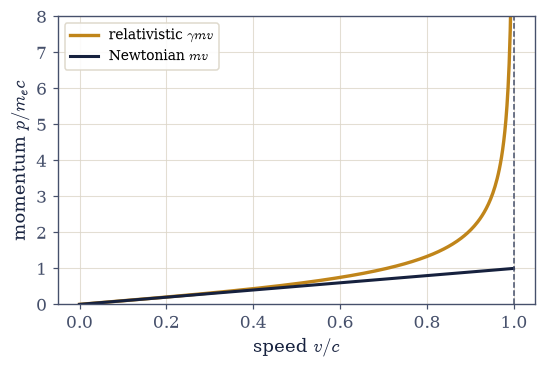

In [9]:
# (solution hidden on the public site)


## Exercise 4 — E = mc² and the low-speed expansion

Now the famous result, and it is not an add-on but a reading of the four-momentum. At rest
($v=0$, $\gamma=1$) the energy $E=\gamma mc^2$ becomes simply $E=mc^2$, the **rest energy**:
mass is a form of energy, and a stationary electron already holds $0.511\,$MeV
{eq}`eq-emc2`. Expanding $E=\gamma mc^2$ for $v\ll c$ gives $mc^2+\tfrac12mv^2+\cdots$ — the
rest energy plus exactly Newton's kinetic energy, with the next term suppressed by $(v/c)^2$.
Newton's $\tfrac12mv^2$ was the first correction to the rest energy all along. The
relativistic kinetic energy $K=(\gamma-1)mc^2$ matches $\tfrac12mv^2$ at low speed and
diverges at $c$ ({numref}`fig-fm-kinetic`).

**This exercise (worked).** Evaluate the electron's rest energy $mc^2$; then at a small
$v=10^{-3}c$ compare the exact $E=\gamma mc^2$ with $mc^2+\tfrac12mv^2$ as plain `numpy`
arithmetic and confirm they agree to floating-point (the omitted $\tfrac38mv^4/c^2$ is
negligible). Plot the relativistic and Newtonian kinetic energies together.

In [10]:
# (solution hidden on the public site)


electron rest energy mc² = 8.1871e-14 J = 0.5110 MeV

at v = 1e-3 c:
  exact  E = γmc²        = 8.187109874837e-14 J
  mc² + ½mv²             = 8.187109874834e-14 J
  relative difference    = 3.75e-13


### Validation 4

In [11]:
validate.close(
    E_exact_small,
    M_E * C_LIGHT**2 + 0.5 * M_E * v_small**2,
    "at low speed the energy is the rest energy plus the Newtonian kinetic energy",
    rtol=1e-12,
    atol=0.0,  # SI energies ~1e-14 J; without this the default atol=1e-9 floor makes rtol inert
)

✓  at low speed the energy is the rest energy plus the Newtonian kinetic energy   [got 8.18711e-14 vs expected 8.18711e-14 (rtol=1e-12)]


True

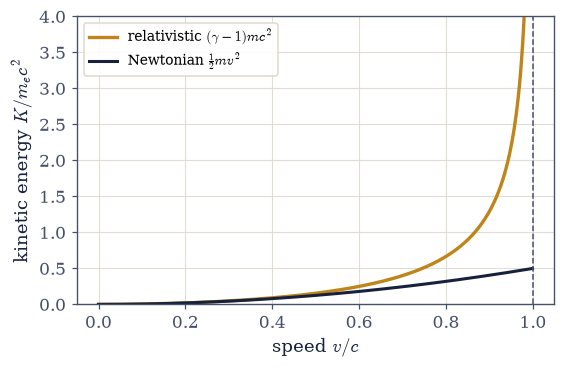

In [12]:
# (solution hidden on the public site)


## Exercise 5 — The invariant mass relation

The four-momentum has a norm, and like every four-vector norm it is the same in every frame.
Computing $\eta_{\mu\nu}p^\mu p^\nu=-(mc)^2$ and rearranging gives the master equation of
relativistic dynamics, $E^2-(pc)^2=(mc^2)^2$ {eq}`eq-invariant-mass`, a "relativistic
Pythagoras" relating energy, momentum, and mass. The rest mass is the invariant *length* of
the four-momentum: observers disagree about $E$ and $p$ separately, but never about
$E^2-(pc)^2$.

**This exercise (worked).** For the electron of Exercise 3, compute $E^2-(pc)^2$ and confirm
it equals $(mc^2)^2$; then boost the four-momentum with `boost4` (the matrix product `@`),
recompute $E$ and $p$ in the new frame, and confirm $E^2-(pc)^2$ is unchanged — the invariant
mass is frame-independent.

In [13]:
# (solution hidden on the public site)


E² − (pc)²  (original frame) = 6.702870e-27 J²
E² − (pc)²  (0.5c frame)     = 6.702870e-27 J²
(mc²)²                       = 6.702870e-27 J²
invariant under the boost: True


### Validation 5

In [14]:
validate.close(
    np.array([inv_rest, inv_boost]),
    np.array([target, target]),
    "E²−(pc)²=(mc²)² is frame-independent (holds before and after a boost)",
    rtol=1e-9,
)

✓  E²−(pc)²=(mc²)² is frame-independent (holds before and after a boost)   [max|Δ| = 0 (rtol=1e-09, atol=1e-09)]


True

## Exercise 6 — Massless particles: E = pc

The invariant relation has a striking limit. Set the mass to zero, and $E^2-(pc)^2=0$ gives
$E=pc$ exactly {eq}`eq-invariant-mass`. A **massless** particle still carries energy and
momentum, locked together as $E=pc$, and must move at exactly $c$ (any other speed would need
$\gamma m$ with $m=0$, which is zero or undefined). This is the photon. It is also why light
carries momentum and exerts **radiation pressure** — the Poynting flux of [§3.10](../03-electrodynamics/radiation.ipynb) delivers
momentum $E/c$ for energy $E$.

**This exercise (student).** Construct a massless four-momentum moving along $x$, $p^\mu=
(E/c)(1,1,0,0)$, and confirm its `four_norm` is zero. Building it that way makes $E=pc$ true
by construction, so test the physics where it is *not* built in: boost $p^\mu$ to a frame
receding at $0.5c$ with `boost4` and confirm with `np.linalg.norm` that in the new frame
$E'=p'c$ still holds, with $E'/E$ equal to the relativistic Doppler factor
$\sqrt{(1-\beta)/(1+\beta)}$ — a boost rescales a null four-momentum but cannot tilt it
off the light cone.

In [15]:
# (solution hidden on the public site)


photon energy E = 2.0 eV
four-momentum norm η_μν p^μ p^ν = 0.000e+00  (zero → massless)
in the 0.5c frame:  E' = 1.1547 eV,  p'c = 1.1547 eV  →  E' = p'c
E'/E = 0.577350   vs Doppler factor √((1−β)/(1+β)) = 0.577350


### Validation 6

In [16]:
validate.close(
    np.array([E_ph_b, E_ph_b / E_photon]),
    np.array([pc_ph_b, doppler]),
    "a boosted photon keeps E'=p'c, rescaled by the Doppler factor √((1−β)/(1+β))",
    rtol=1e-12,
    atol=0.0,  # the E'=p'c Joule component ~1e-19; without this the atol=1e-9 floor makes rtol inert
)

✓  a boosted photon keeps E'=p'c, rescaled by the Doppler factor √((1−β)/(1+β))   [max|Δ| = 2.22045e-16 (rtol=1e-12, atol=0)]


True

## Exercise 7 — The speed limit is dynamical

We can now see *why* nothing massive reaches $c$, and it is not because velocities "cap". A
particle can always be pushed harder; what runs away is its momentum, not its speed. Since
$p=\gamma mv$ and $\gamma\to\infty$ as $v\to c$ {eq}`eq-speed-limit`, the momentum and energy
diverge while the speed creeps ever closer to $c$ without reaching it
({numref}`fig-fm-diverge`). The cosmic speed limit is enforced by the infinite cost of the
last sliver of speed — a dynamical statement, not a kinematic decree.

**This exercise (student).** Tabulate $p=\gamma mv$ in units of $mc$ at $v=0.5c$, $0.9c$,
$0.99c$, $0.999c$ as plain `numpy` arithmetic, and confirm with a comparison that it grows
without bound while $v$ stays below $c$. The figure plots $p/mc$ and $E/mc^2$ diverging at the
limit.

In [17]:
# (solution hidden on the public site)


   v/c        p/mc (= γβ)        E/mc² (= γ)
  0.500          0.577              1.155
  0.900          2.065              2.294
  0.990          7.018              7.089
  0.999         22.344             22.366

p/mc grows without bound while v stays below c: True


### Validation 7

In [18]:
validate.check(
    grows,
    "the speed limit is enforced by diverging momentum, not by velocity capping",
)

✓  the speed limit is enforced by diverging momentum, not by velocity capping


True

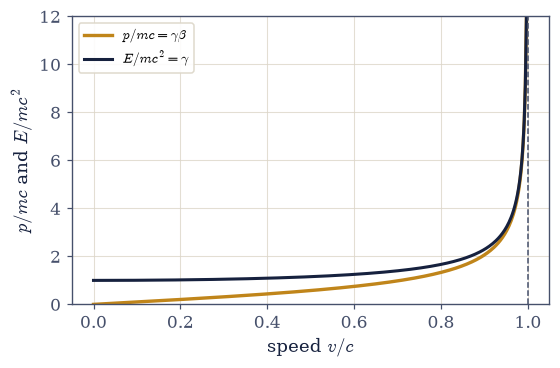

In [19]:
# (solution hidden on the public site)


## Exercise 8 — Mass, energy, momentum: one object

Stand back and see what a single demand produced. We asked only that momentum conservation be
frame-independent, and that requirement forced us to differentiate by proper time, build the
four-velocity, and multiply by mass — and out fell a four-vector whose spatial part is the
relativistic momentum and whose time part is the energy. $E=mc^2$ is then not an isolated
marvel but the rest value of that energy, the time component of momentum seen by an observer
the object is not moving relative to. Mass, energy, and momentum are three faces of one
four-vector, and the rest mass is its invariant length. The universe does its dynamical
bookkeeping in four-momentum, and we merely learned to read the ledger.

**This exercise.** Close with the unifying check that ties the notebook together: confirm with
`np.allclose` that for the electron of Exercise 3 the energy, momentum, and mass satisfy the
invariant $E^2=(pc)^2+(mc^2)^2$ — the single equation containing the rest energy ($p=0$), the
massless limit ($m=0$), and everything between.

In [20]:
# (solution hidden on the public site)


E²        = 1.861908e-26 J²
(pc)²+(mc²)² = 1.861908e-26 J²
E² = (pc)² + (mc²)² holds: True
energy, momentum, and mass are one four-vector; its length is the mass


### Validation 8

In [21]:
validate.check(
    unified,
    "E²=(pc)²+(mc²)² — energy, momentum, and mass are one object",
)

✓  E²=(pc)²+(mc²)² — energy, momentum, and mass are one object


True

## Notebook summary

- **Newtonian momentum fails** {eq}`eq-newton-fails`: a collision conserving $\sum mv$ in the
  lab does not conserve it in a frame boosted at $0.6c$ (the velocities transform nonlinearly),
  so relativity needs a new momentum.
- **Four-velocity and four-momentum** {eq}`eq-four-velocity`, {eq}`eq-four-momentum`:
  $u^\mu=\gamma(c,\mathbf v)$ has the invariant norm $u\cdot u=-c^2$ (via the `np.einsum`
  toolkit of [§4.3](spacetime-minkowski.ipynb)), and $p^\mu=mu^\mu=(E/c,\mathbf p)$ gives $\mathbf p=\gamma m\mathbf v$ and
  $E=\gamma mc^2$ with frame-independent conservation.
- **E = mc²** {eq}`eq-emc2`: the rest energy is the time component at rest ($0.511\,$MeV for
  the electron); expanding $\gamma mc^2$ at $v=10^{-3}c$ reproduces $mc^2+\tfrac12mv^2$ to
  floating point, and $K=(\gamma-1)mc^2$ matches $\tfrac12mv^2$ at low speed.
- **The invariant mass relation** {eq}`eq-invariant-mass`: $E^2-(pc)^2=(mc^2)^2$ is unchanged
  by a boost; for $m=0$ it gives $E=pc$ (the photon, with `four_norm` zero), preserved under a
  $0.5c$ boost with the Doppler rescaling $\sqrt{(1-\beta)/(1+\beta)}$ — the basis of
  radiation pressure ([§3.10](../03-electrodynamics/radiation.ipynb)).
- **The dynamical speed limit** {eq}`eq-speed-limit`: $p=\gamma mv$ and $E=\gamma mc^2$ diverge
  as $v\to c$ ($p/mc=22.3$ at $0.999c$), so reaching $c$ costs infinite energy — the limit is
  enforced by dynamics, not by velocities capping.

Mass, energy, and momentum are one four-vector, bound by $E^2=(pc)^2+(mc^2)^2$.

## Outlook

- **Relativistic collisions and decays ([§4.6](collisions-decays.ipynb)).** Four-momentum conservation in action:
  thresholds, particle creation, and annihilation, where $E^2-(pc)^2$ does the heavy lifting.
- **The relativistic Lagrangian and motion in fields ([§4.7](relativistic-lagrangian-fields.ipynb)).** Dynamics in an electromagnetic
  field, tying back to the field tensor $F^{\mu\nu}$ of [§3.12](../03-electrodynamics/relativistic-maxwell.ipynb).
- **Binding energy and the mass defect.** Nuclear energy as $\Delta m\,c^2$ (a pointer).
- **Massless particles and radiation pressure.** The $E=pc$ photon, a callback to the Poynting
  flux and radiation of [§3.10](../03-electrodynamics/radiation.ipynb).
- **Cross-reference** [§4.3](spacetime-minkowski.ipynb) (four-vectors and the `np.einsum` toolkit reused here) and [§3.12](../03-electrodynamics/relativistic-maxwell.ipynb)
  (four-momentum in the covariant formulation).

In [22]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>